In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
!pip install ultralytics -q
from ultralytics import YOLO
from pathlib import Path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
# -----------------------------
# Paths
# -----------------------------

MODEL_PATH = "/kaggle/input/models/nadantikaap/yolo/pytorch/default/1/best.pt"

VIDEO_PATH = "/kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4"

OUTPUT_DIR = Path("/kaggle/working/")

OUTPUT_DIR.mkdir(exist_ok=True)

In [13]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise Exception("Could not open video.")

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = total_frames / fps

print(f"FPS          : {fps}")
print(f"Resolution   : {width} x {height}")
print(f"Frames       : {total_frames}")
print(f"Duration     : {duration:.2f} sec")

FPS          : 26.333
Resolution   : 1920 x 1012
Frames       : 715
Duration     : 27.15 sec


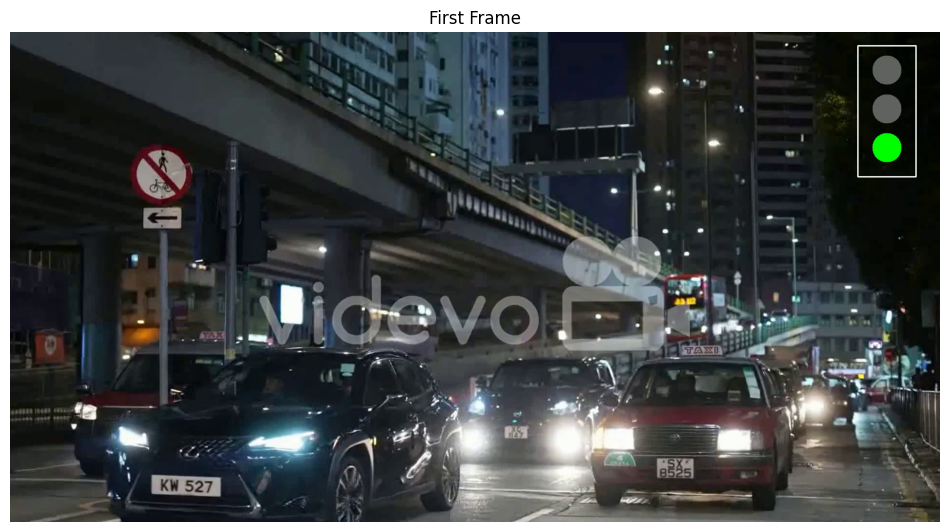

In [17]:
##first frame
ret, frame = cap.read()

if not ret:
    raise Exception("Couldn't read frame.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("First Frame")
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

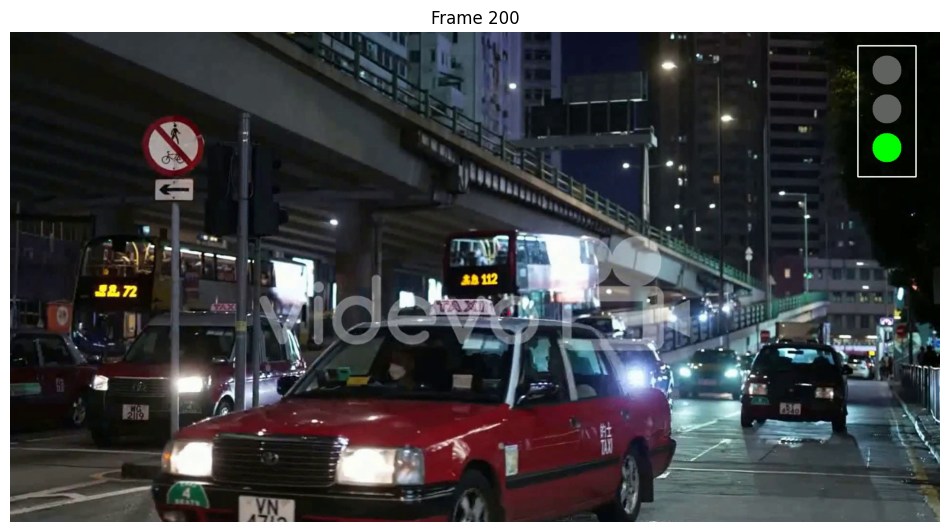

In [18]:
##20th frame

frame_number = 200

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(frame_rgb)
plt.title(f"Frame {frame_number}")
plt.axis("off")

In [19]:
model = YOLO(MODEL_PATH)

print("YOLO loaded successfully.")

YOLO loaded successfully.



0: 704x1280 3 persons, 8 cars, 1 bus, 1 truck, 4 traffic signs, 520.6ms
Speed: 21.3ms preprocess, 520.6ms inference, 25.1ms postprocess per image at shape (1, 3, 704, 1280)


(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

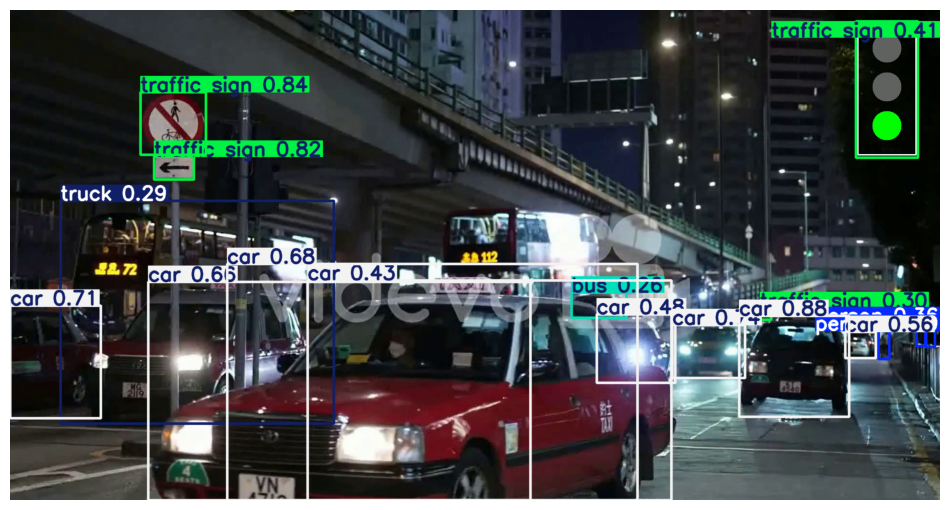

In [20]:
results = model.predict(
    frame,
    imgsz=1280,
    conf=0.25
)

annotated = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [21]:
results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 321ms
Prepared 1 package in 79ms
Installed 1 package in 7ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect




video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 339.2ms
video 1/1 (frame 2/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 328.2ms
video 1/1 (frame 3/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 342.8ms
video 1/1 (frame 4/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 324.3ms
video 1/1 (frame 5/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 309.8ms
video 1/1 (frame 6/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red

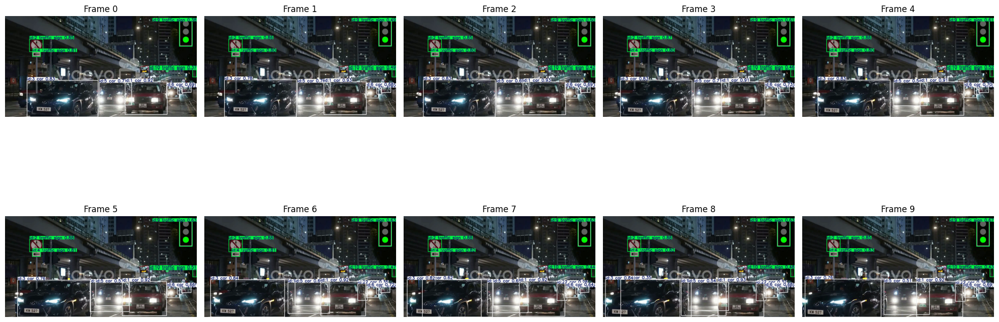

In [22]:
tracked_frames = []

for i, r in enumerate(results):

    frame = r.plot()

    tracked_frames.append(frame)

    if i == 9:
        break

plt.figure(figsize=(20,10))

for i, frame in enumerate(tracked_frames):

    plt.subplot(2,5,i+1)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    plt.title(f"Frame {i}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

first_result = next(results)

print(first_result.boxes)


video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 4 traffic signs, 328.7ms
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2., 8., 8., 2., 2., 2., 8., 8., 2., 2.])
conf: tensor([0.9201, 0.8495, 0.8100, 0.7699, 0.6853, 0.5561, 0.3837, 0.3717, 0.6074, 0.8278])
data: tensor([[1.1805e+03, 6.6038e+02, 1.6184e+03, 9.9565e+02, 1.0000e+00, 9.2011e-01, 2.0000e+00],
        [2.4528e+02, 2.3595e+02, 3.8023e+02, 3.5920e+02, 2.0000e+00, 8.4946e-01, 8.0000e+00],
        [2.7411e+02, 3.6187e+02, 3.5605e+02, 4.0916e+02, 4.0000e+00, 8.1004e-01, 8.0000e+00],
        [8.9112e+02, 6.6698e+02, 1.2697e+03, 9.3485e+02, 5.0000e+00, 7.6987e-01, 2.0000e+00],
        [1.6187e+03, 7.0364e+02, 1.7433e+03, 8.2135e+02, 6.0000e+00, 6.8534e-01, 2.0000e+00],
        [1.7258e+03, 7.1607e+02, 1.7732e+03, 7.8401e+02, 8.0000e+00, 5.5615e-01, 2.0000e+00],
        [1.7456e+03, 2.5782e+01, 1.8745e+

In [24]:
for box in first_result.boxes:

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cls = int(box.cls)

    conf = float(box.conf)

    track_id = int(box.id) if box.id is not None else -1

    print(
        f"ID:{track_id} "
        f"Class:{model.names[cls]} "
        f"Conf:{conf:.2f}"
    )

ID:1 Class:car Conf:0.92
ID:2 Class:traffic sign Conf:0.85
ID:4 Class:traffic sign Conf:0.81
ID:5 Class:car Conf:0.77
ID:6 Class:car Conf:0.69
ID:8 Class:car Conf:0.56
ID:9 Class:traffic sign Conf:0.38
ID:10 Class:traffic sign Conf:0.37
ID:7 Class:car Conf:0.61
ID:23 Class:car Conf:0.83


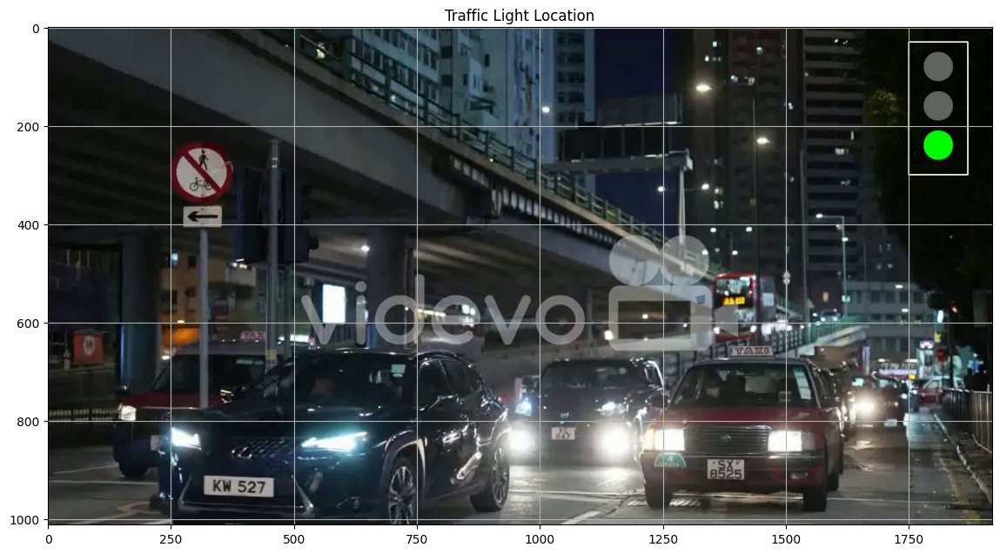

In [25]:
##traffic light coordinates 
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)

ret, frame = cap.read()

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,8))
plt.imshow(frame)
plt.title("Traffic Light Location")
plt.grid()
plt.show()

(np.float64(-0.5), np.float64(119.5), np.float64(254.5), np.float64(-0.5))

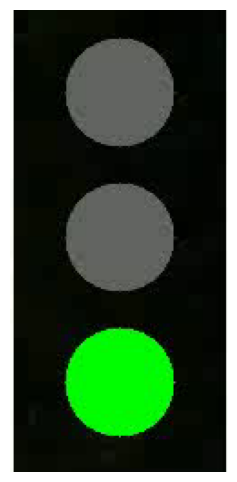

In [28]:
##crop traffic light 
TRAFFIC_LIGHT = (1750, 35, 1870, 290)
x1, y1, x2, y2 = TRAFFIC_LIGHT

crop = frame[y1:y2, x1:x2]

plt.figure(figsize=(4,6))
plt.imshow(crop)
plt.axis("off")

In [30]:
##detect light color 
import cv2
import numpy as np

def detect_light(frame, roi):

    x1, y1, x2, y2 = roi

    crop = frame[y1:y2, x1:x2]

    hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)

    red1 = cv2.inRange(hsv,
                       np.array([0,120,120]),
                       np.array([10,255,255]))

    red2 = cv2.inRange(hsv,
                       np.array([170,120,120]),
                       np.array([180,255,255]))

    red = cv2.bitwise_or(red1, red2)

    green = cv2.inRange(hsv,
                        np.array([40,80,80]),
                        np.array([90,255,255]))

    yellow = cv2.inRange(hsv,
                         np.array([15,100,100]),
                         np.array([35,255,255]))

    r = cv2.countNonZero(red)
    g = cv2.countNonZero(green)
    y = cv2.countNonZero(yellow)

    if r > g and r > y:
        return "RED"

    if g > r and g > y:
        return "GREEN"

    return "YELLOW"

In [31]:
state = detect_light(frame, TRAFFIC_LIGHT)

print(state)

GREEN


In [45]:

# Stop line 

STOP_LINE = (
    (0, 925),    # Left point
    (2000, 980)    # Right point
)

(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

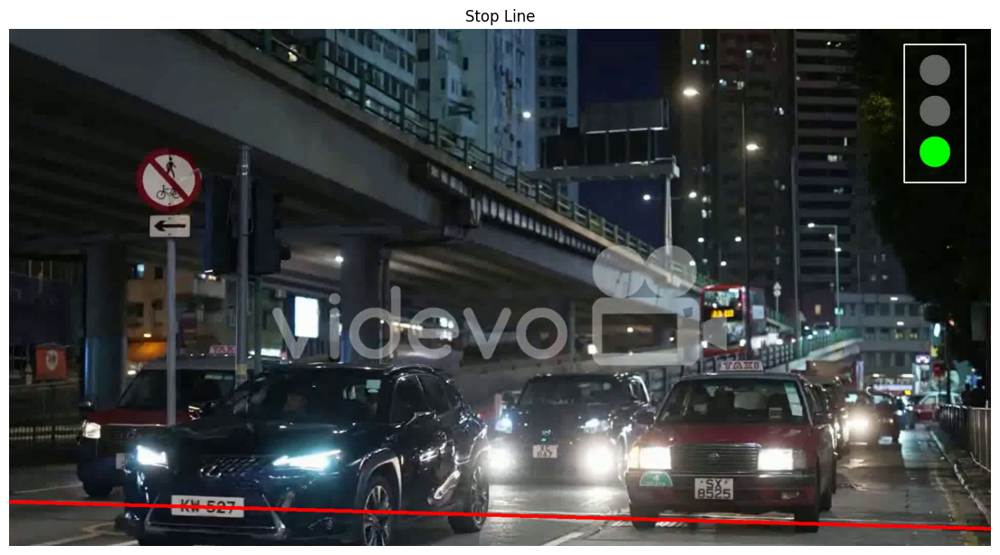

In [46]:
#draw the stop line 

frame_copy = frame.copy()

cv2.line(
    frame_copy,
    STOP_LINE[0],
    STOP_LINE[1],
    (255,0,0),
    5
)

plt.figure(figsize=(14,8))
plt.imshow(frame_copy)
plt.title("Stop Line")
plt.axis("off")

In [48]:
def bottom_center(box):

    x1, y1, x2, y2 = box

    cx = int((x1 + x2) / 2)
    cy = int(y2)

    return cx, cy

In [50]:
STOP_Y = STOP_LINE[0][1]
previous_position = {}
violated = set()

In [52]:
results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

previous_position = {}
violated = set()

for frame_idx, result in enumerate(results):

    # Get traffic light state for THIS frame
    frame = result.orig_img
    current_light = detect_light(
        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
        TRAFFIC_LIGHT
    )

    # Process every tracked vehicle
    for box in result.boxes:

        if box.id is None:
            continue

        track_id = int(box.id)

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        cx = int((x1 + x2) / 2)
        cy = int(y2)          # bottom center

        if track_id not in previous_position:
            previous_position[track_id] = cy
            continue

        previous_y = previous_position[track_id]

        crossed = previous_y < STOP_Y and cy >= STOP_Y

        if crossed and current_light == "RED":

            violated.add(track_id)

            print(
                f"Frame {frame_idx}: Vehicle {track_id} ran the red light!"
            )

        previous_position[track_id] = cy


video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 4 traffic signs, 328.4ms
video 1/1 (frame 2/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 317.9ms
video 1/1 (frame 3/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 8 cars, 5 traffic signs, 319.4ms
video 1/1 (frame 4/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 300.7ms
video 1/1 (frame 5/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 311.4ms
video 1/1 (frame 6/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red

In [53]:
from pathlib import Path
import cv2

results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "/kaggle/working/tracked.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

for result in results:

    frame = result.plot()

    writer.write(frame)

writer.release()

print("Done!")


video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 1 car, 1 traffic sign, 290.2ms
video 1/1 (frame 2/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 319.7ms
video 1/1 (frame 3/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 326.2ms
video 1/1 (frame 4/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 318.4ms
video 1/1 (frame 5/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 325.4ms
video 1/1 (frame 6/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-l


video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 1 car, 1 traffic sign, 312.8ms
video 1/1 (frame 2/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 312.9ms
video 1/1 (frame 3/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 319.3ms
video 1/1 (frame 4/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 315.5ms
video 1/1 (frame 5/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 326.2ms
video 1/1 (frame 6/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-l

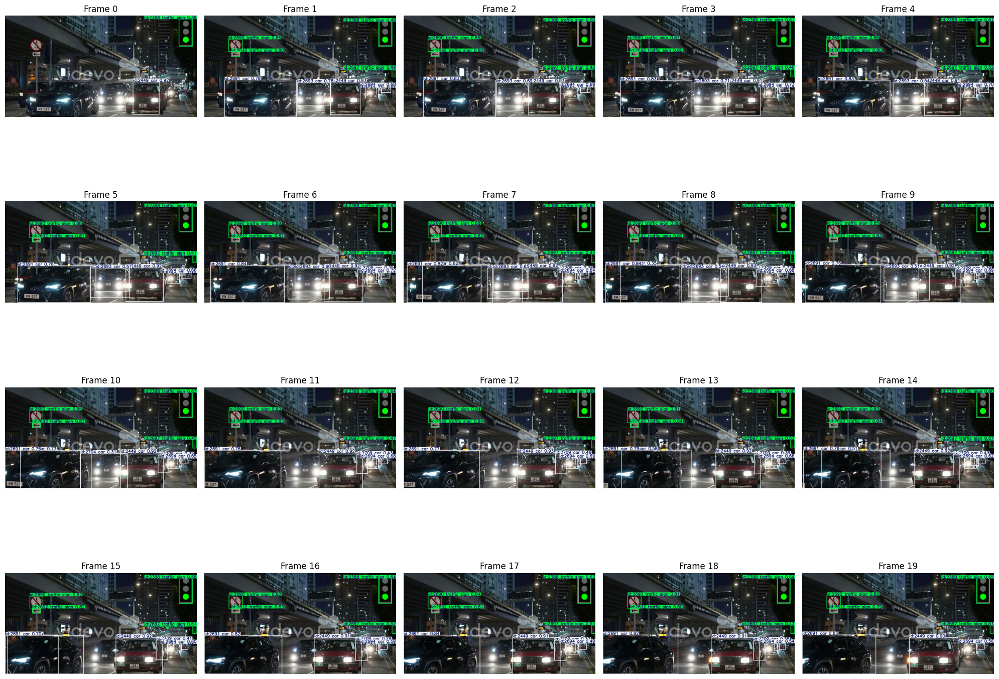

In [55]:
import cv2
import matplotlib.pyplot as plt

results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

frames = []

for i, result in enumerate(results):

    annotated = result.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    frames.append(annotated)

    if i == 19:      # First 20 frames
        break

plt.figure(figsize=(20,16))

for i, img in enumerate(frames):

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(f"Frame {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
previous_position = {}

violated = set()

violation_frames = {}

In [57]:
def bottom_center(box):

    x1, y1, x2, y2 = box

    cx = int((x1+x2)/2)

    cy = int(y2)

    return cx, cy

In [61]:
import random

# Total number of frames in the video
TOTAL_FRAMES = 715   # or use total_frames from your video info

# Pick 20 random frame numbers
random_frames = sorted(random.sample(range(TOTAL_FRAMES), 20))

results = model.track(
    source=VIDEO_PATH,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    imgsz=1280,
    conf=0.25
)

frames = []
random_set = set(random_frames)

for frame_number, result in enumerate(results):

    # Skip frames that are not in our random sample
    if frame_number not in random_set:
        continue

    frame = result.orig_img.copy()
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    current_light = detect_light(rgb, TRAFFIC_LIGHT)

    annotated = result.plot()

    # Draw stop line
    cv2.line(
        annotated,
        STOP_LINE[0],
        STOP_LINE[1],
        (255, 0, 0),
        4
    )

    # Display traffic light state
    cv2.putText(
        annotated,
        f"LIGHT: {current_light}",
        (50, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0, 255, 0),
        3
    )

    frames.append((frame_number, cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)))

    if len(frames) == 20:
        break


video 1/1 (frame 1/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 5 cars, 4 traffic signs, 284.8ms
video 1/1 (frame 2/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 284.7ms
video 1/1 (frame 3/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 7 cars, 5 traffic signs, 277.3ms
video 1/1 (frame 4/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 288.0ms
video 1/1 (frame 5/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4: 704x1280 6 cars, 5 traffic signs, 292.4ms
video 1/1 (frame 6/715) /kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red

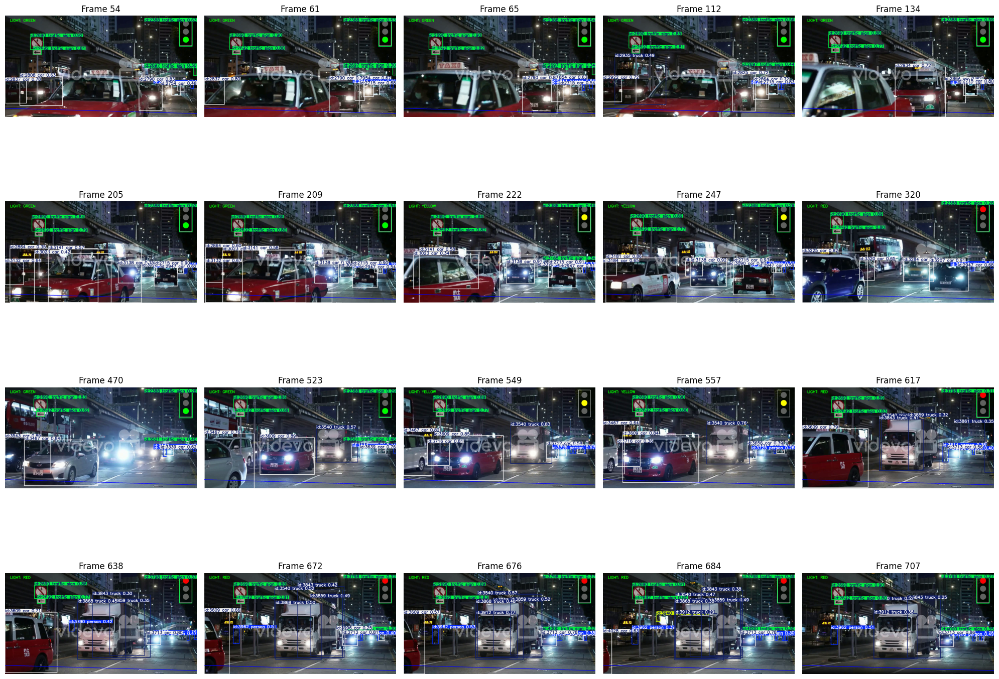

In [63]:
plt.figure(figsize=(20,16))

for i, (frame_no, img) in enumerate(frames):
    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(f"Frame {frame_no}")
    plt.axis("off")

plt.tight_layout()
plt.show()